In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import gzip
from io import BytesIO
sns.set_theme(style="whitegrid")
print("Libraries loaded")

Libraries loaded


In [2]:
DATASET = "isoc_e_dii"
URL = f"https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{DATASET}?format=TSV&compressed=true"

print(f"Fetching {DATASET}...")
r = requests.get(URL, timeout=60, headers={'User-Agent': 'Mozilla/5.0'})
r.raise_for_status()
print(f"Got {len(r.content):,} bytes")

with gzip.open(BytesIO(r.content), 'rt', encoding='utf-8') as f:
    raw_dii = pd.read_csv(f, sep='\t')
print(f"Loaded {len(raw_dii):,} rows")
print(f"Header: {raw_dii.columns[0]}")

Fetching isoc_e_dii...


Got 45,364 bytes
Loaded 3,478 rows
Header: freq,size_emp,nace_r2,indic_is,unit,geo\TIME_PERIOD


In [3]:
first_col = raw_dii.columns[0]
dim_part = first_col.split('\\')[0]
dim_names = [d.strip() for d in dim_part.split(',')]

dii = raw_dii.copy()
dii[dim_names] = dii[first_col].str.split(',', expand=True)
for d in dim_names:
    dii[d] = dii[d].astype(str).str.strip()
dii = dii.drop(columns=[first_col])

year_cols = [c for c in dii.columns if c not in dim_names]
dii_long = dii.melt(id_vars=dim_names, value_vars=year_cols,
                     var_name='year', value_name='value_raw')
dii_long['year'] = dii_long['year'].astype(str).str.strip().astype(int)
dii_long['value_raw'] = dii_long['value_raw'].astype(str).str.strip()
dii_long['value'] = pd.to_numeric(
    dii_long['value_raw'].str.extract(r'(-?\d+\.?\d*)')[0],
    errors='coerce'
)

print(f"Long format: {len(dii_long):,} rows")
print(f"Years: {sorted(dii_long['year'].unique())}")
print(f"DII indicators present: {[i for i in dii_long['indic_is'].unique() if 'DI' in str(i)][:8]}")

Long format: 38,258 rows
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
DII indicators present: ['E_DI2_HI', 'E_DI2_LO', 'E_DI2_VHI', 'E_DI2_VLO', 'E_DI3_GELO', 'E_DI3_HI', 'E_DI3_LO', 'E_DI3_VHI']


In [4]:
COUNTRIES = ['LT', 'EU27_2020', 'LV', 'PL', 'DE', 'EE', 'SE', 'NL', 'IT', 'ES', 'FI', 'IE']

indicator = 'E_DI3_GELO'

dii_focus = dii_long[
    (dii_long['indic_is'] == indicator) &
    (dii_long['geo'].isin(COUNTRIES)) &
    (dii_long['unit'] == 'PC_ENT') &
    (dii_long['value'].notna())
].copy()

print(f"Using indicator: {indicator}")
print(f"Rows after filter: {len(dii_focus)}")

lt_years = dii_focus[dii_focus['geo'] == 'LT']['year'].unique()
latest_year = max(lt_years) if len(lt_years) else dii_focus['year'].max()
print(f"Latest year: {latest_year}")

dii_latest = dii_focus[dii_focus['year'] == latest_year].copy()
print(f"Countries with data in {latest_year}: {sorted(dii_latest['geo'].unique())}")
print(f"Size classes available: {sorted(dii_latest['size_emp'].unique())}")


Using indicator: E_DI3_GELO
Rows after filter: 189
Latest year: 2025
Countries with data in 2025: ['DE', 'EE', 'ES', 'EU27_2020', 'FI', 'IE', 'IT', 'LT', 'LV', 'NL', 'PL', 'SE']
Size classes available: ['0-9', '0_1', '10-249', '10-49', '2-9', '50-249', 'GE10', 'GE250']


Using size class: GE10


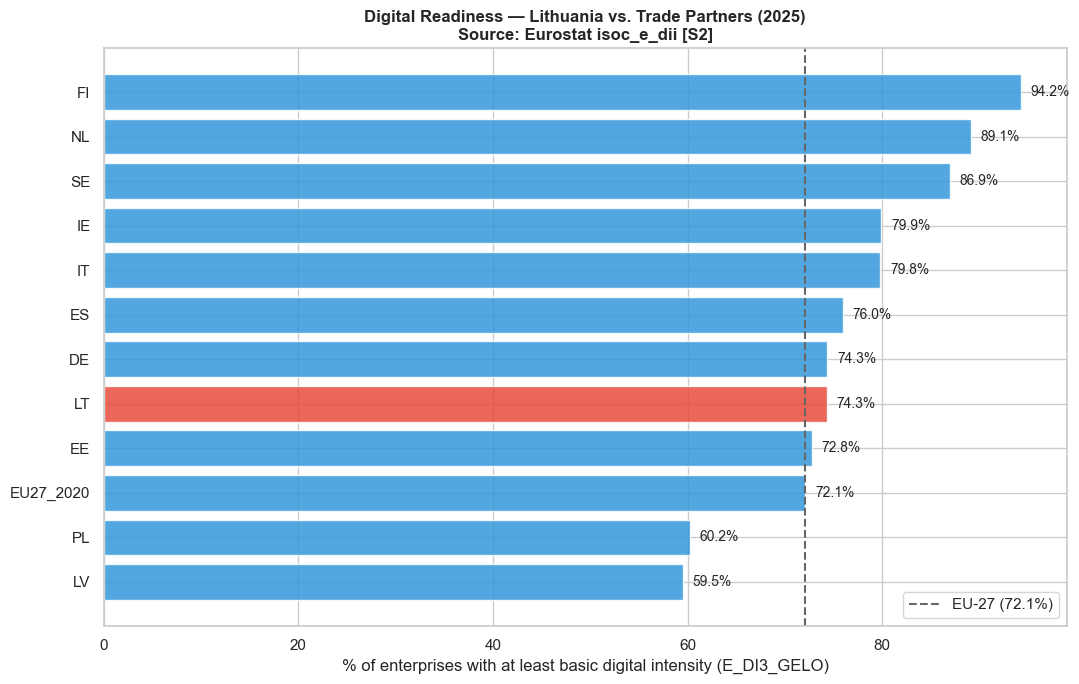


Lithuania: [74.34]
EU-27: [72.11]


In [5]:
# Try common SME size codes — Eurostat varies these between datasets
size_candidates = ['SM_C10_S951_XK', '10_249', 'SM', 'GE10', '10_C10_S951_XK']
sme_data = pd.DataFrame()
for sc in size_candidates:
    cand = dii_latest[dii_latest['size_emp'] == sc]
    if len(cand) >= 5:
        sme_data = cand
        print(f"Using size class: {sc}")
        break

if len(sme_data) == 0:
    best = dii_latest.groupby('size_emp')['geo'].nunique().idxmax()
    sme_data = dii_latest[dii_latest['size_emp'] == best]
    print(f"Fallback size class: {best}")

sme_sorted = sme_data.sort_values('value', ascending=True)
colors = ['#e74c3c' if g == 'LT' else '#3498db' for g in sme_sorted['geo']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(sme_sorted['geo'], sme_sorted['value'], color=colors, alpha=0.85)
for bar, val in zip(bars, sme_sorted['value']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

eu_val = sme_sorted[sme_sorted['geo'] == 'EU27_2020']['value']
if len(eu_val):
    ax.axvline(eu_val.iloc[0], color='#666', linestyle='--', linewidth=1.5,
               label=f'EU-27 ({eu_val.iloc[0]:.1f}%)')
    ax.legend(loc='lower right')

ax.set_xlabel(f"% of enterprises with at least basic digital intensity (E_DI3_GELO)")
ax.set_title(f"Digital Readiness — Lithuania vs. Trade Partners ({latest_year})\nSource: Eurostat isoc_e_dii [S2]",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("../reports/lt_digital_readiness_gap.png", dpi=150)
plt.show()

print(f"\nLithuania: {sme_data[sme_data['geo']=='LT']['value'].values}")
print(f"EU-27: {sme_data[sme_data['geo']=='EU27_2020']['value'].values}")


## 6. Cross-reference: Partner DII vs LT SME export gap

**Hypothesis:** LT SMEs are underrepresented in markets whose enterprises run at higher digital intensity than LT's. We test two framings:

1. *Absolute:* SME share of LT exports to country C vs. C's enterprise DII
2. *Relative:* SME share vs. (C's DII − LT's DII) — the digital readiness gap

If digital readiness is a barrier, both should show a negative correlation.

This section recomputes notebook 01's `material` DataFrame inline so this notebook runs end-to-end on its own.

In [6]:
# 6.1 — Rebuild notebook 01's `material` DataFrame inline (self-contained).
ext_tec = pd.read_csv('../data/ext_tec10.csv.gz', compression='gzip')
lt_exp = ext_tec[
    (ext_tec['geo'] == 'LT') &
    (ext_tec['unit'] == 'THS_EUR') &
    (ext_tec['stk_flow'] == 'EXP') &
    (ext_tec['TIME_PERIOD'] == 2024)
].copy()
lt_exp['OBS_VALUE'] = pd.to_numeric(lt_exp['OBS_VALUE'], errors='coerce')

# Pivot by partner ISO code (so we can join on `geo` from the DII data)
pivot = lt_exp.pivot_table(
    index=['partner', 'Geopolitical entity (partner)'],
    columns='sizeclas', values='OBS_VALUE', aggfunc='sum', fill_value=0
).reset_index()

# Drop Eurostat aggregates (EU27, World, EFTA, ...): real ISO2 codes are 2 chars
pivot = pivot[pivot['partner'].str.len() == 2].copy()

pivot['SME_total']     = pivot[['LT10', '10-49', '50-249']].sum(axis=1)
pivot['Large_total']   = pivot['GE250']
pivot['Country_total'] = pivot['SME_total'] + pivot['Large_total']

# Materiality filter (matches notebook 01 §8): >EUR 50M total exports in 2024
material = pivot[pivot['Country_total'] > 50_000].copy()
material['SME_share_pct'] = material['SME_total'] / material['Country_total'] * 100
print(f"Material partner countries (>EUR 50M LT exports, 2024): {len(material)}")

# 6.2 — Partner-country DII for the EU SME size class (10-249 employees)
SME_SIZE = '10-249'
dii_partner = dii_long[
    (dii_long['indic_is'] == 'E_DI3_GELO') &
    (dii_long['unit']     == 'PC_ENT') &
    (dii_long['size_emp'] == SME_SIZE) &
    (dii_long['year']     == latest_year) &
    (dii_long['value'].notna())
][['geo', 'value']].rename(columns={'geo': 'partner', 'value': 'partner_DII'})

lt_dii = dii_partner.loc[dii_partner['partner'] == 'LT', 'partner_DII'].iloc[0]
print(f"LT SME (size {SME_SIZE}) DII in {latest_year}: {lt_dii:.1f}%")

overlap = sorted(set(material['partner']) & set(dii_partner['partner']))
print(f"Partner ISO codes with both trade and DII data ({len(overlap)}): {overlap}")

# 6.3 — Merge: inner join only keeps partners present in both datasets
xref = material.merge(dii_partner, on='partner', how='inner').copy()
xref['DII_gap']  = xref['partner_DII'] - lt_dii
xref['country']  = xref['Geopolitical entity (partner)']
xref = xref[['partner', 'country', 'SME_share_pct', 'partner_DII',
             'DII_gap', 'Country_total']].sort_values('SME_share_pct').reset_index(drop=True)
print(f"\nMerged dataset: {len(xref)} partner countries")
print(xref.to_string(index=False))


Material partner countries (>EUR 50M LT exports, 2024): 45
LT SME (size 10-249) DII in 2025: 73.5%
Partner ISO codes with both trade and DII data (25): ['AT', 'BE', 'BG', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LV', 'NL', 'NO', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'TR']

Merged dataset: 25 partner countries
partner     country  SME_share_pct  partner_DII  DII_gap  Country_total
     EL      Greece      34.659576        55.95   -17.56      119641.28
     NL Netherlands      36.252266        88.76    15.25     1859835.67
     RO     Romania      40.048857        44.34   -29.17      232171.77
     ES       Spain      40.767805        75.35     1.84      498110.82
     SK    Slovakia      42.902814        57.09   -16.42      190005.60
     HR     Croatia      44.379249        57.09   -16.42       58893.20
     IT       Italy      44.541251        79.49     5.98      876042.43
     EE     Estonia      45.810670        72.12    -1.39     1980472.88
     AT    

In [ ]:
from scipy import stats

# Drop LT itself (self-comparison: gap=0, not informative)
plot_df = xref[xref['partner'] != 'LT'].copy()

x_abs = plot_df['partner_DII'].values
x_gap = plot_df['DII_gap'].values
y     = plot_df['SME_share_pct'].values

r_abs, p_abs = stats.pearsonr(x_abs, y)
r_gap, p_gap = stats.pearsonr(x_gap, y)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

def panel(ax, x, y_, labels, title, xlabel, r, p):
    ax.scatter(x, y_, s=80, color='#3498db', alpha=0.75,
               edgecolor='white', linewidth=1.2)
    slope, intercept = np.polyfit(x, y_, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope*xs + intercept, '--', color='#e74c3c', linewidth=2,
            label=f'OLS fit (slope={slope:+.2f})')
    for xi, yi, lbl in zip(x, y_, labels):
        ax.annotate(lbl, (xi, yi), xytext=(5, 4),
                    textcoords='offset points', fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("SME share of LT exports to country (%)")
    ax.set_title(f"{title}\nPearson r = {r:+.2f}   (p = {p:.3f}, n = {len(x)})",
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

panel(axes[0], x_abs, y, plot_df['partner'].values,
      "Absolute: Partner DII vs SME share",
      f"Partner enterprise DII (size {SME_SIZE}, {latest_year}, %)",
      r_abs, p_abs)

panel(axes[1], x_gap, y, plot_df['partner'].values,
      "Relative: DII gap (Partner − LT) vs SME share",
      "Digital readiness gap vs LT (percentage points)",
      r_gap, p_gap)

fig.suptitle(
    f"Does partner-country digital readiness predict LT SME under-representation? ({latest_year})\n"
    f"Source: Eurostat ext_tec10 [S1] + isoc_e_dii [S2]",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("../reports/lt_dii_vs_sme_share.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("CORRELATION SUMMARY")
print("=" * 60)
print(f"Absolute (Partner DII):    r = {r_abs:+.3f}, p = {p_abs:.4f}")
print(f"Relative (DII gap vs LT):  r = {r_gap:+.3f}, p = {p_gap:.4f}")
print(f"n = {len(plot_df)} partner countries with both trade and DII data")


### Section 6 findings (fill in after running)

Replace this cell with the observed `r_abs` / `r_gap` and the deck-ready
interpretation. Direction guide:

- **Strong negative slope on the absolute panel** → markets with mature digital
  ecosystems crowd out LT SMEs; the gap is structural, not a transient lag.
- **Strong negative slope on the relative panel** → the *relative* readiness
  deficit (LT vs partner) is what binds — investing in LT SME digital
  capabilities directly addresses the export gap.
- **Weak / null correlation in both** → digital readiness alone doesn't explain
  the SME export gap; revisit notebook 01 §8 dimensions B/C (logistics costs,
  language, regulatory complexity) as alternative drivers.

**Caveat:** n is bounded by Eurostat DII coverage (~30 European partners).
The biggest underserved markets from notebook 01 §8 — US, CN, GB, RU — are
*not* in this regression; the correlation answers a European-partner question
only. For non-EU underserved markets, supplement with OECD or World Bank
digital-economy indicators in a follow-up section.